# Práctica Evaluable - Unidad 3
## Generador de Titulares con Miniature GPT

| Campo | Valor |
|---|---|
| **Nombre** | *(Tu nombre aquí)* |
| **Unidad** | 3 - Arquitectura Transformers y Acceso Programático |
| **Tipo** | Práctica individual |
| **Basado en** | [Tutorial Keras - Text generation with a miniature GPT](https://keras.io/examples/generative/text_generation_with_miniature_gpt/) |

---

### Objetivo
Implementar un modelo Transformer desde cero para generar titulares de noticias en español, consolidando los conceptos teóricos de la arquitectura Transformer aplicándolos en código real.

---
## Parte 1: Preparación del Entorno

Antes de construir el modelo, configuramos el entorno de trabajo, importamos las librerías necesarias y descargamos el dataset. Se utiliza Google Colab con GPU para acelerar el entrenamiento.

> ⚠️ **Importante:** Asegúrate de activar la GPU antes de ejecutar: *Entorno de ejecución > Cambiar tipo de entorno de ejecución > GPU*

In [ ]:
# Instalar gdown si no está disponible
!pip install gdown -q

In [ ]:
# Verificar GPU en Colab
import tensorflow as tf
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

# Imports
import numpy as np
import keras
from keras import layers
import matplotlib.pyplot as plt

GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Descargar dataset
!gdown 199dxi24ln2b-_S4mhH2sgpr3nvxmoxZN -O titulares.txt

# Cargar texto
with open('titulares.txt', 'r', encoding='utf-8') as f:
    text = f.read()

print(f"Caracteres totales: {len(text)}")
print(f"\nMuestra:\n{text[:500]}")

Downloading...
From: https://drive.google.com/uc?id=199dxi24ln2b-_S4mhH2sgpr3nvxmoxZN
To: /content/titulares.txt
100% 60.4k/60.4k [00:00<00:00, 68.6MB/s]
Caracteres totales: 60438

Muestra:
nueva ley de energia promete revolucionar el sector electrico
el cambio climatico sigue siendo una amenaza global
inversionistas buscan oportunidades en energias renovables
aumenta la demanda de vehiculos electricos
vacunas contra covid19 cuando estaremos todos protegidos
el debate sobre las vacunas sigue dividiendo opiniones
expertos en salud analizan la efectividad de las vacunas
vacunacion masiva contra el coronavirus en marcha
el mercado de criptomonedas se dispara a nuevas alturas
es bitcoi


### 📝 Reflexión - Parte 1

*(Escribe aquí tus observaciones sobre el dataset: ¿Cuántos caracteres tiene? ¿Qué tipo de titulares contiene? ¿Qué observas en la muestra?)*

---
## Parte 2: Tokenización a Nivel de Carácter

La tokenización convierte texto en secuencias de números que el modelo puede procesar. En esta práctica usamos **tokenización a nivel de carácter** porque:
- Simplifica la implementación
- Permite comprender el flujo completo sin tokenizadores externos
- Vocabulario pequeño (~70-100 tokens)

**Comparativa de estrategias de tokenización:**
| Nivel | Vocabulario | Longitud de secuencia | Uso típico |
|---|---|---|---|
| Carácter | ~70-100 tokens | Larga | Prácticas, modelos pequeños |
| Subpalabra (BPE) | ~30.000-50.000 | Media | GPT, BERT, LLMs modernos |
| Palabra | Muy grande | Corta | Modelos clásicos |

In [ ]:
# Crear vocabulario
vocab = sorted(set(text))
vocab_size = len(vocab)
print(f"Vocabulario: {vocab_size} caracteres únicos")
print(f"Caracteres: {vocab}")

# Mapeos carácter <-> índice
char_to_idx = {ch: i for i, ch in enumerate(vocab)}
idx_to_char = {i: ch for i, ch in enumerate(vocab)}

def encode(s):
    return [char_to_idx[c] for c in s]

def decode(ids):
    return ''.join([idx_to_char[i] for i in ids])

# Test de encode/decode
test_str = "hola"
encoded = encode(test_str)
print(f"\nTest encode('{test_str}'): {encoded}")
print(f"Test decode({encoded}): {decode(encoded)}")

Vocabulario: 33 caracteres únicos
Caracteres: ['\n', ' ', '1', '2', '3', '4', '7', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'x', 'y', 'z']

Test encode('hola'): [15, 22, 19, 8]
Test decode([15, 22, 19, 8]): hola


### 📝 Reflexión - Parte 2

*(Explica con tus propias palabras qué hace el proceso de tokenización aquí. ¿Por qué el modelo necesita trabajar con números en lugar de caracteres directamente? ¿Qué ventajas y desventajas tiene la tokenización a nivel de carácter frente a la de subpalabras?)*

---
## Parte 3: Preparar Datos de Entrenamiento

Para entrenar un modelo de lenguaje autoregresivo usamos **teacher forcing**: la entrada es una secuencia de tokens y la salida es la misma secuencia desplazada una posición a la derecha.

**Ejemplo:**
- Secuencia original: `[H, o, l, a]`
- **Entrada (X):** `[H, o, l]`
- **Salida (y):** `[o, l, a]`

El modelo aprende a predecir el siguiente carácter dado el contexto anterior.

In [ ]:
# Parámetros de datos
SEQ_LENGTH = 80   # Ventana de contexto (un titular típico tiene 40-100 chars)
BATCH_SIZE = 64   # Secuencias por batch

# Tokenizar todo el corpus
tokens = np.array(encode(text))
print(f"Total de tokens: {len(tokens)}")

# Crear secuencias X (entrada) e y (objetivo)
def crear_secuencias(tokens, seq_len):
    X, y = [], []
    for i in range(len(tokens) - seq_len):
        X.append(tokens[i:i+seq_len])
        y.append(tokens[i+1:i+seq_len+1])
    return np.array(X), np.array(y)

X, y = crear_secuencias(tokens, SEQ_LENGTH)
print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")

# Dataset de TensorFlow optimizado para GPU
dataset = tf.data.Dataset.from_tensor_slices((X, y))
dataset = dataset.shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
print(f"\nDataset creado correctamente ✓")

Total de tokens: 60438
Shape X: (60358, 80)
Shape y: (60358, 80)

Dataset creado correctamente ✓


### 📝 Reflexión - Parte 3

*(Explica el concepto de teacher forcing. ¿Por qué se usa? ¿Qué significa que SEQ_LENGTH=80 sea la 'ventana de contexto'? ¿Qué pasaría si usáramos una ventana más grande o más pequeña?)*

---
## Parte 4: Componentes del Transformer

Esta es la parte central de la práctica. Implementamos los dos componentes fundamentales de la arquitectura Transformer:

1. **Token & Position Embedding:** Convierte tokens e índices de posición en vectores densos.
2. **Transformer Block:** Contiene atención multi-cabeza con máscara causal, FFN y conexiones residuales.

### 4.1 Embeddings con Posición

Los Transformers no tienen recurrencia, por lo que necesitan **embeddings posicionales** para conocer el orden de los tokens. Sumamos el embedding del token con el embedding de su posición.

> 💡 **Conexión con la teoría:** En el paper original *"Attention Is All You Need"* se usan embeddings posicionales sinusoidales (fijos). Aquí usamos embeddings posicionales **aprendidos**, que es la estrategia de GPT.

In [ ]:
class TokenAndPositionEmbedding(layers.Layer):
    """Suma el embedding del token con el embedding de su posición."""

    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

print("TokenAndPositionEmbedding definido ✓")

TokenAndPositionEmbedding definido ✓


### 4.2 Bloque Transformer con Atención Causal

El bloque Transformer implementa la secuencia: **Multi-Head Attention → Add & Norm → Feed-Forward → Add & Norm**

La **máscara causal** es esencial: impide que cada posición "vea" tokens futuros, haciendo el modelo autoregresivo.

| Componente | Función |
|---|---|
| Multi-Head Attention | Atiende a diferentes partes de la secuencia simultáneamente |
| Máscara causal | Matriz triangular inferior: posición *i* solo ve posiciones 0...*i* |
| Feed-Forward (FFN) | Dos capas densas con activación GELU, procesa cada posición |
| LayerNorm + Residual | Estabiliza el entrenamiento y permite apilar múltiples bloques |

In [ ]:
class TransformerBlock(layers.Layer):
    """Bloque Transformer con atención causal (autoregresivo)."""

    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="gelu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)

    def causal_attention_mask(self, batch_size, seq_len):
        """Máscara triangular inferior: cada posición solo ve tokens anteriores."""
        i = tf.range(seq_len)[:, tf.newaxis]
        j = tf.range(seq_len)
        mask = tf.cast(i >= j, dtype=tf.float32)
        mask = tf.reshape(mask, [1, 1, seq_len, seq_len])
        return tf.tile(mask, [batch_size, 1, 1, 1])

    def call(self, inputs, training=None):
        batch_size = tf.shape(inputs)[0]
        seq_len = tf.shape(inputs)[1]
        mask = self.causal_attention_mask(batch_size, seq_len)

        # Multi-Head Attention + Add & Norm
        attn_output = self.att(inputs, inputs, attention_mask=mask)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)

        # Feed-Forward + Add & Norm
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

print("TransformerBlock definido ✓")

TransformerBlock definido ✓


### 📝 Reflexión - Parte 4

*(Explica con tus propias palabras qué hace la máscara causal y por qué es imprescindible para la generación de texto. ¿Qué diferencia hay entre los embeddings posicionales sinusoidales del paper original y los aprendidos que usamos aquí? ¿Por qué se usan conexiones residuales?)*

---
## Parte 5: Modelo Completo

Ensamblamos los componentes apilando varios bloques Transformer. La capa de salida `Dense(vocab_size, softmax)` produce una distribución de probabilidad sobre el vocabulario para cada posición.

| Hiperparámetro | Valor | Descripción |
|---|---|---|
| `EMBED_DIM` | 256 | Dimensión de los embeddings |
| `NUM_HEADS` | 4 | Cabezas de atención (cada una de dim 64) |
| `FF_DIM` | 512 | Dimensión interna de la FFN |
| `NUM_BLOCKS` | 4 | Bloques Transformer apilados |

In [ ]:
# Hiperparámetros del modelo
EMBED_DIM = 256
NUM_HEADS = 4
FF_DIM = 512
NUM_BLOCKS = 4

def crear_modelo():
    inputs = layers.Input(shape=(SEQ_LENGTH,), dtype=tf.int32)
    x = TokenAndPositionEmbedding(SEQ_LENGTH, vocab_size, EMBED_DIM)(inputs)
    for _ in range(NUM_BLOCKS):
        x = TransformerBlock(EMBED_DIM, NUM_HEADS, FF_DIM)(x)
    outputs = layers.Dense(vocab_size, activation="softmax")(x)
    return keras.Model(inputs=inputs, outputs=outputs)

model = crear_modelo()
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding    │ (None, 80, 256)        │        28,928 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 80, 256)        │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 80, 256)        │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 80, 256)        │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 80, 256)        │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 80, 33)         │         8,481 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,300,769 (20.22 MB)

 Trainable params: 5,300,769 (20.22 MB)

 Non-trainable params: 0 (0.00 B)

### 📝 Reflexión - Parte 5

*(Observa el resumen del modelo: ¿Cuántos parámetros tiene en total? ¿Qué capa tiene más parámetros? ¿Por qué la capa de salida usa softmax? ¿Qué representan sus salidas?)*

---
## Parte 6: Entrenamiento

Entrenamos con **sparse categorical crossentropy** (ideal para etiquetas como índices enteros). Los callbacks controlan el proceso:
- `EarlyStopping`: detiene el entrenamiento si la pérdida no mejora en 3 épocas.
- `ReduceLROnPlateau`: reduce la tasa de aprendizaje a la mitad si se estanca.

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2)
]

history = model.fit(dataset, epochs=30, callbacks=callbacks)

Epoch 1/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 112s 94ms/step - accuracy: 0.7224 - loss: 0.8802 - learning_rate: 0.0010
Epoch 2/30
  1/944 ━━━━━━━━━━━━━━━━━━━━ 1:59 127ms/step - accuracy: 0.6529 - loss: 1.4030

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


944/944 ━━━━━━━━━━━━━━━━━━━━ 87s 92ms/step - accuracy: 0.9000 - loss: 0.3107 - learning_rate: 0.0010
Epoch 3/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 87s 92ms/step - accuracy: 0.9287 - loss: 0.2185 - learning_rate: 0.0010
Epoch 4/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 87s 92ms/step - accuracy: 0.9368 - loss: 0.1927 - learning_rate: 0.0010
Epoch 5/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 87s 92ms/step - accuracy: 0.9410 - loss: 0.1788 - learning_rate: 0.0010
Epoch 6/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 87s 92ms/step - accuracy: 0.9438 - loss: 0.1689 - learning_rate: 0.0010
Epoch 7/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 87s 92ms/step - accuracy: 0.9457 - loss: 0.1625 - learning_rate: 0.0010
Epoch 8/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 87s 92ms/step - accuracy: 0.9474 - loss: 0.1570 - learning_rate: 0.0010
Epoch 9/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 87s 92ms/step - accuracy: 0.9486 - loss: 0.1529 - learning_rate: 0.0010
Epoch 10/30
944/944 ━━━━━━━━━━━━━━━━━━━━ 87s 92ms/step - accuracy: 0.9496 - loss: 0.1496 - learning_rate: 0.0010
Ep

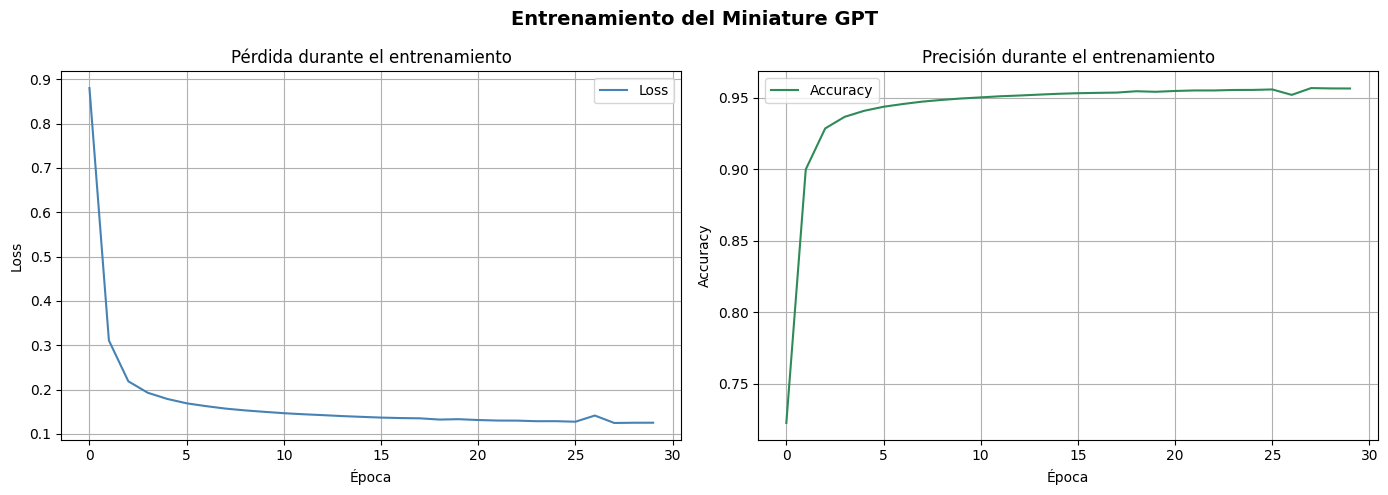


Mejor loss: 0.1245
Mejor accuracy: 0.9569


In [ ]:
# Visualización de curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pérdida
axes[0].plot(history.history['loss'], label='Loss', color='steelblue')
axes[0].set_title('Pérdida durante el entrenamiento')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Precisión
axes[1].plot(history.history['accuracy'], label='Accuracy', color='seagreen')
axes[1].set_title('Precisión durante el entrenamiento')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Entrenamiento del Miniature GPT', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nMejor loss: {min(history.history['loss']):.4f}")
print(f"Mejor accuracy: {max(history.history['accuracy']):.4f}")

### 📝 Reflexión - Parte 6

*(Describe las curvas de entrenamiento: ¿Convergió el modelo? ¿En qué época activó el EarlyStopping? ¿El loss descendió de forma suave o hubo picos? ¿Qué accuracy final obtuviste y qué significa ese valor para este tipo de tarea?)*

---
## Parte 7: Generación de Texto

La generación es **autoregresiva**: el modelo predice un carácter, lo añade a la secuencia y predice el siguiente.

El parámetro **temperatura** controla la aleatoriedad:
| Temperatura | Comportamiento | Resultado |
|---|---|---|
| 0.5 | Conservador | Más coherente, puede ser repetitivo |
| 1.0 | Equilibrado | Balance creatividad / coherencia |
| 1.5 | Aleatorio | Más creativo, puede ser incoherente |

In [ ]:
def generar_texto(model, inicio, longitud=100, temperatura=1.0):
    """Genera texto de forma autoregresiva dado un texto de inicio."""
    generado = list(encode(inicio))

    for _ in range(longitud):
        input_seq = generado[-SEQ_LENGTH:]
        input_seq = np.array(input_seq)[np.newaxis, :]

        # Padding si la secuencia es más corta que SEQ_LENGTH
        if len(input_seq[0]) < SEQ_LENGTH:
            pad_len = SEQ_LENGTH - len(input_seq[0])
            input_seq = np.pad(input_seq, ((0, 0), (pad_len, 0)))

        # Predicción con temperatura
        preds = model.predict(input_seq, verbose=0)[0, -1, :]
        preds = np.log(preds + 1e-10) / temperatura
        preds = np.exp(preds) / np.sum(np.exp(preds))
        next_idx = np.random.choice(len(preds), p=preds)
        generado.append(next_idx)

        # Parar en salto de línea (fin de titular)
        if idx_to_char[next_idx] == '\n':
            break

    return decode(generado)

print("Función de generación definida ✓")

Función de generación definida ✓


In [ ]:
print("=" * 50)
print("=== Temperatura 0.5 (conservador) ===")
print("=" * 50)
print(generar_texto(model, "el gobierno ", temperatura=0.5))

print("\n" + "=" * 50)
print("=== Temperatura 1.0 (equilibrado) ===")
print("=" * 50)
print(generar_texto(model, "el gobierno ", temperatura=1.0))

print("\n" + "=" * 50)
print("=== Temperatura 1.5 (creativo) ===")
print("=" * 50)
print(generar_texto(model, "el gobierno ", temperatura=1.5))

=== Temperatura 0.5 (conservador) ===


KeyError: 'E'

In [ ]:
# Experimentación con diferentes textos de inicio
inicios = ["la economía ", "un nuevo ", "el presidente ", "argentina ", "se espera "]

print("=" * 50)
print("Generación con temperatura 0.8")
print("=" * 50)

for inicio in inicios:
    resultado = generar_texto(model, inicio, temperatura=0.8)
    print(f"\n📰 Inicio: '{inicio}'")
    print(f"   → {resultado}")

### 📝 Análisis y Reflexión Final - Parte 7

Responde a las siguientes preguntas basándote en los resultados obtenidos:

**1. Patrones aprendidos:**
*(¿El modelo genera palabras reales en español? ¿Genera estructuras gramaticales básicas? ¿Los titulares tienen coherencia temática?)*

**2. Efecto de la temperatura:**
*(¿Qué diferencias observas entre T=0.5, T=1.0 y T=1.5? ¿En qué temperatura obtienes resultados más interesantes?)*

**3. Limitaciones del modelo:**
*(¿Qué fallos comete? ¿Qué mejoraría si usáramos más datos, tokenización por subpalabras o una arquitectura más grande?)*

**4. Reflexión sobre la arquitectura:**
*(¿Qué componente del Transformer crees que ha sido más determinante para la calidad de los resultados? ¿Por qué?)*

---

*(Escribe tu análisis aquí...)*

---
## (Opcional) Experimentación con Hiperparámetros

Si quieres explorar más, prueba a modificar alguno de estos parámetros y documenta los resultados:

In [ ]:
# Ejemplo: probar con más bloques o mayor dimensión de embedding
# EMBED_DIM = 512
# NUM_HEADS = 8
# FF_DIM = 1024
# NUM_BLOCKS = 6

# model_v2 = crear_modelo()
# ...

print("Celda de experimentación opcional")

---
## Conclusiones

*(Escribe aquí un resumen de los aprendizajes de la práctica. ¿Qué ha sido lo más interesante? ¿Y lo más difícil? ¿Cómo conecta esta implementación con los conceptos teóricos de las sesiones?)*

---
*Práctica Evaluable - Unidad 3 | Arquitectura Transformers y Acceso Programático*